In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import joblib

In [15]:
rnn_model = load_model("../models/simplernn_best.keras")
lstm_model = load_model("../models/lstm_tuned_best.keras")

In [16]:
scaler = joblib.load("../models/scaler.pkl")

In [17]:
X_test = np.load("../data/X_test.npy")
Y_test = np.load("../data/y_test.npy")

print(f"X_test: {X_test.shape}")
print(f"Y_test: {Y_test.shape}")

X_test: (484, 60, 1)
Y_test: (484, 1)


In [18]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [19]:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
Y_actual = scaler.inverse_transform(Y_test)

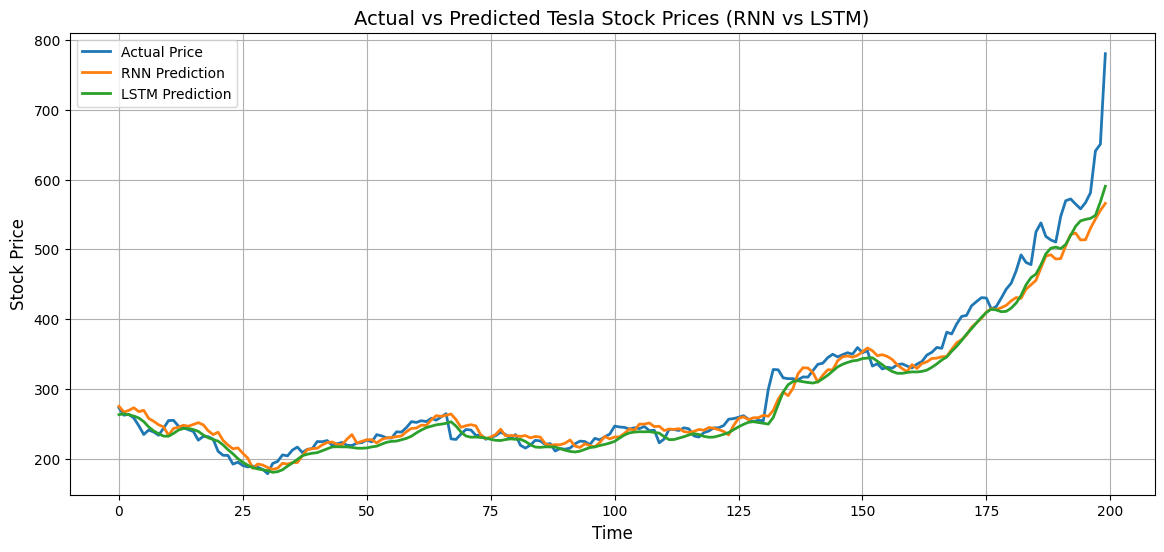

In [20]:
plt.figure(figsize=(14,6))

# Plot last 200 points for better visualization
plt.plot(Y_actual[-200:], label='Actual Price', linewidth=2)
plt.plot(rnn_pred[-200:], label='RNN Prediction', linewidth=2)
plt.plot(lstm_pred[-200:], label='LSTM Prediction', linewidth=2)

plt.legend()
plt.title("Actual vs Predicted Tesla Stock Prices (RNN vs LSTM)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Stock Price", fontsize=12)

plt.grid(True)

# Save image
plt.savefig('../outputs/plots/final_prediction.png')

plt.show()

In [21]:
rnn_mse = mean_squared_error(Y_actual, rnn_pred)
lstm_mse = mean_squared_error(Y_actual, lstm_pred)

print(f"RNN MSE: {rnn_mse}")
print(f"LSTM MSE: {lstm_mse}")

RNN MSE: 453.1307556084607
LSTM MSE: 394.62032044577


In [22]:
def predict_future(model, last_sequence, days):
    future = []
    current_input = last_sequence.reshape(1, 60, 1)

    for _ in range(days):
        next_pred = model.predict(current_input, verbose=0)[0][0]
        future.append(next_pred)

        current_input = np.append(
            current_input[:, 1:, :],
            [[[next_pred]]],
            axis=1
        )

    return np.array(future).reshape(-1, 1)

In [23]:
last_60_days = X_test[-1]

future_1 = predict_future(lstm_model, last_60_days, 1)
future_5 = predict_future(lstm_model, last_60_days, 5)
future_10 = predict_future(lstm_model, last_60_days, 10)

In [24]:
future_1 = scaler.inverse_transform(future_1)
future_5 = scaler.inverse_transform(future_5)
future_10 = scaler.inverse_transform(future_10)

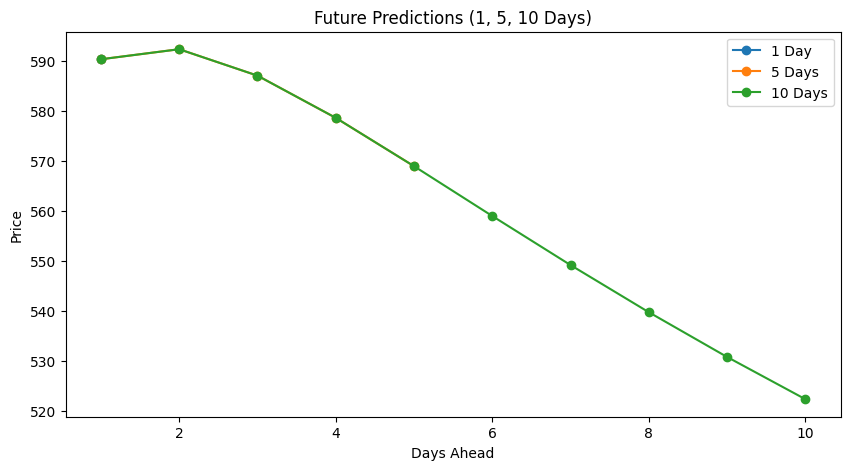

In [25]:
plt.figure(figsize=(10,5))

plt.plot(range(1,2), future_1, marker='o', label="1 Day")
plt.plot(range(1,6), future_5, marker='o', label="5 Days")
plt.plot(range(1,11), future_10, marker='o', label="10 Days")

plt.title("Future Predictions (1, 5, 10 Days)")
plt.xlabel("Days Ahead")
plt.ylabel("Price")
plt.legend()

plt.savefig("../outputs/plots/future_1_5_10_days.png")
plt.show()